In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

data_locust = {
    'Endpoint': [
        'Login', 
        'Join Room', 
        'Cek Ujian', 
        'Mulai Sesi', 
        'Tarik Soal', 
        'Submit Jawaban', 
        'Selesai'
    ],
    'Request Count': [100, 100, 894, 100, 100, 4000, 100],
    'Average Response Time (ms)': [6454.76, 6775.98, 1478.23, 1590.71, 2242.48, 1382.13, 876.00],
    'Median Response Time (ms)': [5700.0, 6200.0, 1100.0, 1600.0, 1900.0, 1300.0, 840.0],
    'Requests/s (RPS)': [0.16, 0.16, 1.41, 0.16, 0.16, 6.33, 0.16]
}

df_load_test = pd.DataFrame(data_locust)


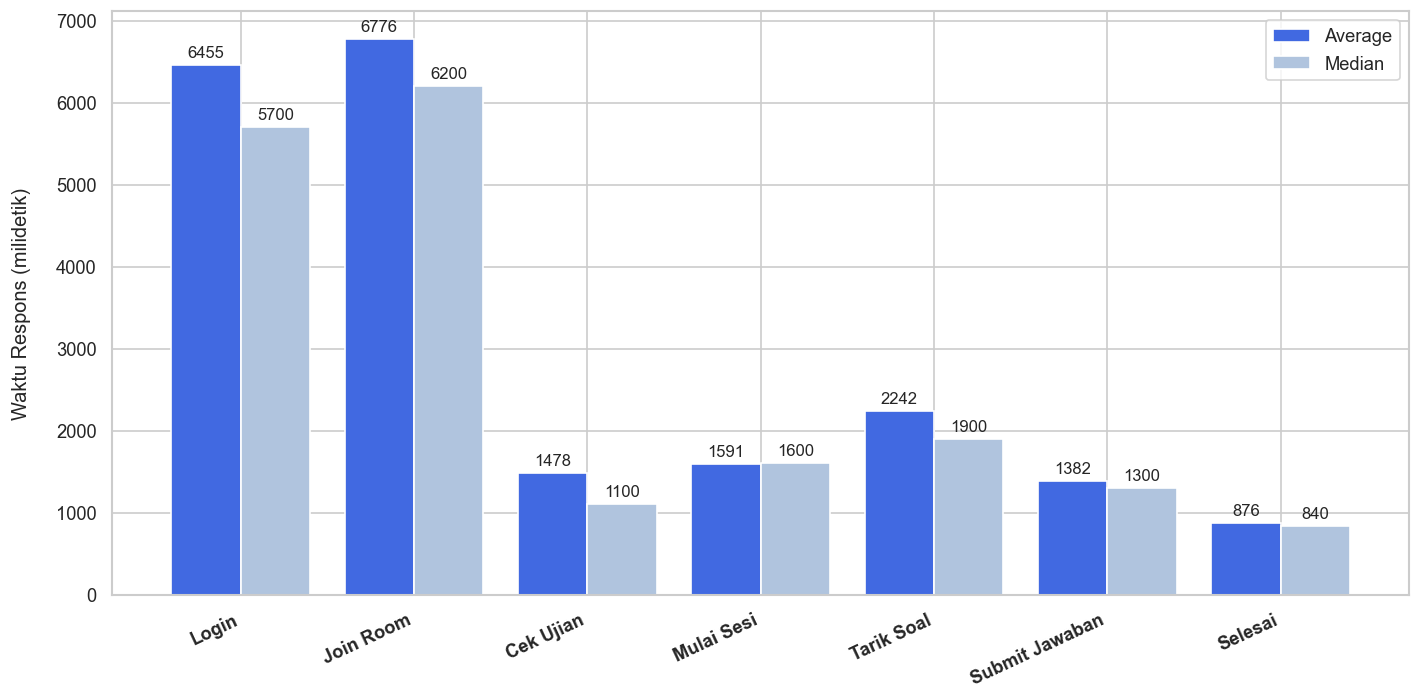

In [9]:
x = np.arange(len(df_load_test['Endpoint']))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, df_load_test['Average Response Time (ms)'], width, 
                label='Average', color='royalblue')
rects2 = ax.bar(x + width/2, df_load_test['Median Response Time (ms)'], width, 
                label='Median', color='lightsteelblue')

ax.set_ylabel('Waktu Respons (milidetik)', fontsize=12, labelpad=15)
# ax.set_title('Perbandingan Waktu Respons per Endpoint API', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(df_load_test['Endpoint'], rotation=25, ha='right', fontsize=11, fontweight='bold')
ax.legend(fontsize=11)

ax.bar_label(rects1, padding=3, fmt='%.0f', fontsize=10)
ax.bar_label(rects2, padding=3, fmt='%.0f', fontsize=10)

plt.tight_layout()
plt.show()

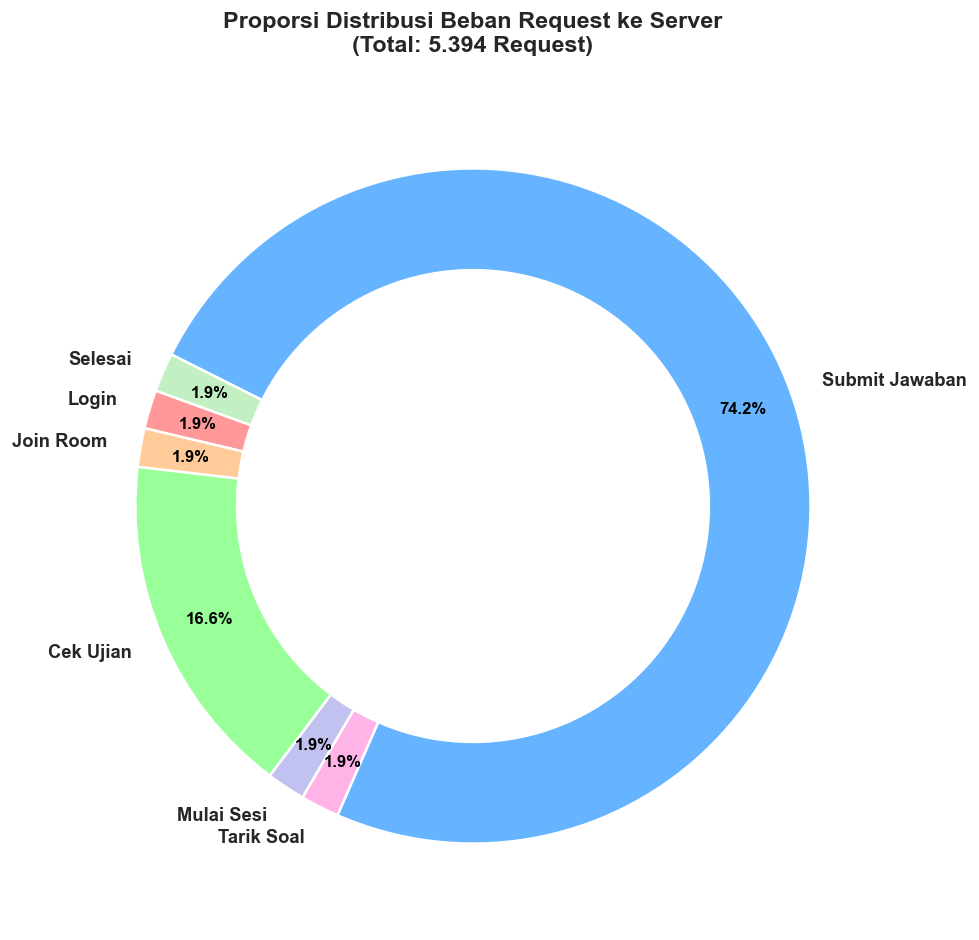

In [6]:
plt.figure(figsize=(9, 8))

colors = ['#ff9999', '#ffcc99', '#99ff99', '#c2c2f0', '#ffb3e6', '#66b3ff', '#c2f0c2']

wedges, texts, autotexts = plt.pie(
    df_load_test['Request Count'], 
    labels=df_load_test['Endpoint'], 
    autopct='%1.1f%%', 
    startangle=160, 
    colors=colors,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.setp(autotexts, size=10, weight="bold", color="black")
plt.title('Proporsi Distribusi Beban Request ke Server\n(Total: 5.394 Request)', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [8]:
print("   Skenario: 100 User, Spawn Rate 10 User/detik")
print("="*65)
print(f"• Total Request Diterima  : 5.394 Request")
print(f"• Total Request Gagal     : 0")
print(f"• Rata-rata Throughput    : 8.54 Request/detik (RPS)")
print("-" * 65)
print("PERFORMA ENDPOINT (Berdasarkan Waktu Respons):")

df_sorted = df_load_test.sort_values('Average Response Time (ms)', ascending=False)

for index, row in df_sorted.iterrows():
    endpoint = row['Endpoint']
    avg_time = row['Average Response Time (ms)']
    req_count = row['Request Count']
    
    detik = avg_time / 1000
    
    print(f"   • {endpoint:<20} : {avg_time:>6.0f} ms ({detik:.1f} detik) | {req_count} request")


   Skenario: 100 User, Spawn Rate 10 User/detik
• Total Request Diterima  : 5.394 Request
• Total Request Gagal     : 0
• Rata-rata Throughput    : 8.54 Request/detik (RPS)
-----------------------------------------------------------------
PERFORMA ENDPOINT (Berdasarkan Waktu Respons):
   • Join Room            :   6776 ms (6.8 detik) | 100 request
   • Login                :   6455 ms (6.5 detik) | 100 request
   • Tarik Soal           :   2242 ms (2.2 detik) | 100 request
   • Mulai Sesi           :   1591 ms (1.6 detik) | 100 request
   • Cek Ujian            :   1478 ms (1.5 detik) | 894 request
   • Submit Jawaban       :   1382 ms (1.4 detik) | 4000 request
   • Selesai              :    876 ms (0.9 detik) | 100 request
